# Aplicaciones de Inferencia Estadística


Usualmente en un curso de Inferencia Estadística se presenta por primera vez la noción de estimación, así como los métodos de estimación puntual y por intervalos. Finalmente se introducen las pruebas de hipótesis y se discuten las particularidades de cada tipo de contraste.


Sin embago se suele perder de vista que toda la teoría desarrollada tiene una gran cantidad de aplicaciones en la vida real, con claras limitantes y supuestos que deben ser considerados ( trabajar con una coleccción de variables aleatorias independientes e idénticamente distribuidas con una distribución conocida pero parámetros desconocidos).

A continuación se presentan algunas implementaciones.


## Concesionaria de Automóviles Motor Nation

Motor Nation es una concesionaria de automóviles en México. En el año 2025 la empresa sufrió una caída en sus ventas que llevó a los directivos a reducir la comisión de los vendedores. El pago de las comisiones estaba condicionado a que el vendedor alcanzara una cuota de ventas mensual de al menos 2 automóviles. Esta medida causó descontento entre los vendedores, quienes argumentaban que la cuota era demasiado alta y que no reflejaba las condiciones del mercado. 

Los trabajadores decidieron organizarse y presentar una queja formal ante la dirección de la empresa, solicitando una revisión de la cuota de ventas y una posible reducción de la misma. Para resolver esta situación, el área de análisis de datos debía determinar si la cuota de ventas de 2 automóviles era razonable o si efectivamente era demasiado alta y debía ser ajustada. 

Para determinar esto, con base en los registros de ventas del 2025 en las sucursales de CDMX, se analizó la probabilidad de que un vendedor perdidiera sus comisiones del mes, es decir, la probabilidad de que un vendedor no alcanzara la cuota de ventas de 2 automóviles al mes. Si la probabilidad era alta, entonces los vendedores tenían razón y la cuota de ventas era demasiado alta para las condiciones del mercado.


Durante el análisis, se consideraron las siguientes preguntas:

1. ¿Cuál es el número promedio de automóviles vendidos por trabajador en un mes?

2. ¿Cuál es la proporción de vendedores que no alcanzan la cuota de ventas al mes? Dicho de otra forma, ¿cuál es la probabilidad de que un vendedor pierda sus comisiones?

3. Bajo la restricción de la cuota de ventas, ¿en el peor escenario cuántos vendedores pueden perder sus comisiones al mes?
¿Y cuántos en el mejor escenario?

4. ¿Se puede decir que la probabilidad de que un vendedor no logre una sola meta de ventas al mes es menor a 0.5? 










## Planteamiento

**El área de análisis de datos sabe que el número de automóviles vendidos por trabajador al mes sigue una distribución Poisson.**

**También suponen que el número de ventas por trabajador al mes es independiente entre sí, es decir, el número de ventas de un trabajador no afecta el número de ventas de otro trabajador.**

**Se cuenta con los registros de ventas de 147 trabajadores de las sucursales de CDMX durante el año 2025.** 


In [ ]:
# Simulacion de los datos. Esto me permite tener certeza de que los datos si son una muestra aleatoria de una distribucion Poisson 
# con un parametro específico (en este caso 3.5) así como comprobar que mis estimaciones son correctas

# En la practica, solo se nos proporciona directamente el archivo csv

ventas_simuladas<- rpois(147, lambda = 3.5)
id<- 1:147
sexo<- sample(c("M", "F"), size = 147, replace = TRUE)
df <- data.frame(id = id, ventas = ventas_simuladas, sexo = sexo)
write.csv(df, "ventas2025.csv", row.names = FALSE)


Primero, visualizamos los registros disponibles, aunque podría no ser evidente que los datos siguen una distribución Poisson, estamos asumiendo que sí lo hacen sin cuestionarlo (como se hacía en Inferencia Estadística).

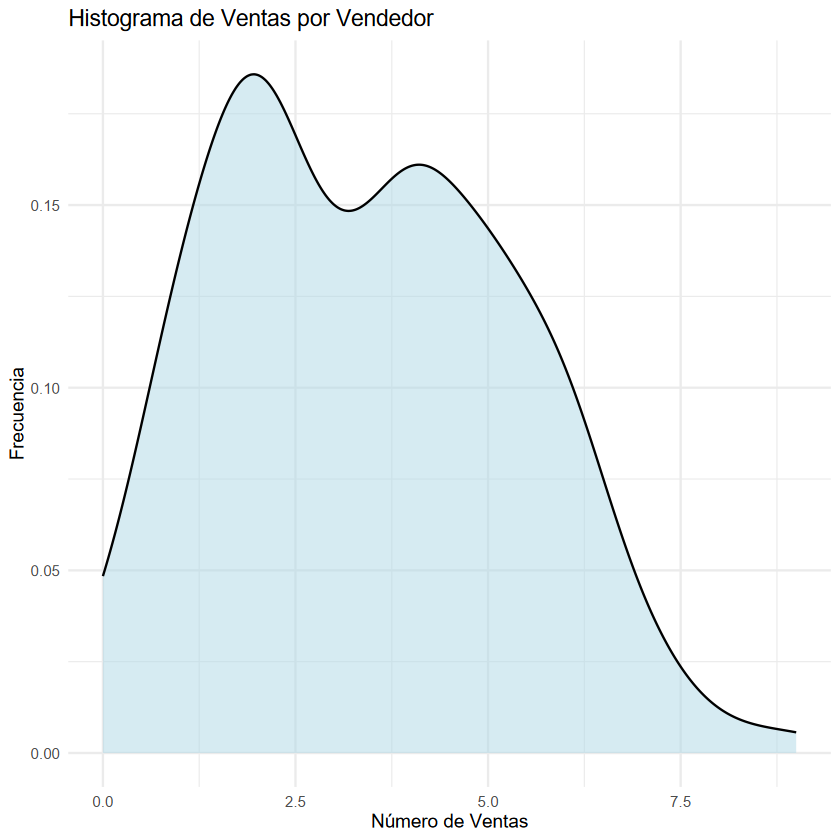

In [1]:
library(ggplot2)

#cargamos los datos de un csv
datos <- read.csv("ventas2025.csv")


ggplot(datos, aes(x = ventas)) +
  geom_density(aes(x=ventas), fill="lightblue", alpha=0.5) +
  labs(title = "Histograma de Ventas por Vendedor",
       x = "Número de Ventas",
       y = "Frecuencia") +
  theme_minimal()

### 1. ¿Cuál es el número promedio de automóviles vendidos por trabajador en un mes?

Como sabemos que el número de ventas por trabajador al mes sigue una distribución Poisson, entonces el número promedio de automóviles vendidos por trabajador en un mes corresponde al parámetro lambda.

Para obtener el estimador de máxima verosimilitud, se puede utilizar la paquete `fitdistrplus`, que permite ajustar a un conjunto de datos una distribución y obtener el valor del estimador de máxima verosimilitud del parámetro (de la distribución elegida para los datos observados). 

Como el estimador de máxima verosimilitud para la distribución Poisson es la media muestral, también se puede calcular directamente utilizando la función `mean()`

In [5]:
library(fitdistrplus)


ajuste_poisson <- fitdist(datos$ventas, "pois")

lambda_MV <- ajuste_poisson$estimate

lambda_media <- mean(datos$ventas)


lambda_MV 

lambda_media

Cargando paquete requerido: MASS

Cargando paquete requerido: survival



lambda 
3.414966

[1] 3.414966

Por lo tanto, el número promedio de automóviles vendidos es 3.41


Los registros muestran que en promedio cada trabajador vende 3.41 automóviles al mes, esto puede sugerir que la cuota de ventas de 2 automóviles al mes es alcanzable para los vendedores. 

### 2. ¿Cuál es la probabilidad de que un vendedor pierda sus comisiones?

Se sabe que la cuota de ventas es de 2 automóviles al mes, por lo tanto, un vendedor pierde sus comisiones si vende 0 o 1 automóvil al mes.

Como se sigue una distribución Poisson, la probabilidad de que un vendedor venda k automóviles o menos se puede calcular como: 


$$P(X \leq k) = \sum_{i=0}^{k} \frac{e^{-\lambda} \lambda^i}{i!}$$

En particular, la probabilidad de que un vendedor pierda sus comisiones se puede calcular como:

$$P(X \leq 1) = P(X = 0) + P(X = 1) = \frac{e^{-\lambda} \lambda^0}{0!} + \frac{e^{-\lambda} \lambda^1}{1!} = e^{-\lambda} + \lambda e^{-\lambda} = e^{-\lambda}(1 + \lambda)$$

Por la propiedad de invarianza de los estimadores de máxima verosimilitud, se puede sustituir el valor del estimador de máxima verosimilitud para obtener la probabilidad de que un vendedor pierda sus comisiones.

$$\hat{\tau(\lambda)}_{MV} = \hat{P}(X \leq 1)_{MV} = e^{-\hat{\lambda}_{MV}}(1 + \hat{\lambda}_{MV})$$



Calculando la probabilidad estimada con los registros disponibles, se obtiene que la probabilidad estimada de que un vendedor pierda sus comisiones es aproximadamente 0.14, lo que sugiere que la mayoría de los vendedores alcanzan la cuota de ventas de 2 automóviles al mes y no pierden sus comisiones.

In [6]:
exp(-lambda_MV) * (1 + lambda_MV)

lambda 
0.1451532

Tambien se puede utilizar la función `ppois()` en R, que calcula la probabilidad acumulada de una distribución de Poisson, para obtener la probabilidad de que un vendedor pierda sus comisiones.

In [ ]:
ppois(1, lambda = lambda_MV) #usamos como el parametro "real" el valor del estimador MV

[1] 0.1451532

### 3. Bajo la restricción de la cuota de ventas, ¿en el peor escenario cuántos vendedores pueden perder sus comisiones al mes? ¿Y cuántos en el mejor escenario?

Para obtener la probabilidad de que un vendedor pierda sus comisiones bajo el mejor y peor escenario, basta con obtener un intervalo de confianza para $\lambda$, y luego calcular el intervalo de confianza de la probabilidad de que un vendedor pierda sus comisiones.

Recordando que un intervalo de confianza para $\lambda$ se obtenía como:

$$
P[L(\underline{X}) \leq \lambda \leq U(\underline{X})] = 1 - \alpha
$$

Si $\tau(\lambda)$ es una función monótona creciente, entonces el intervalo de confianza para $\tau(\lambda)$ se puede obtener como:
$$P[\tau(L(\underline{X})) \leq \tau(\lambda) \leq \tau(U(\underline{X}))] = 1 - \alpha$$

Si $\tau(\lambda)$ es una función monótona decreciente, entonces el intervalo de confianza para $\tau(\lambda)$ se puede obtener como:
$$P[\tau(U(\underline{X})) \leq \tau(\lambda) \leq \tau(L(\underline{X}))] = 1 - \alpha$$


Podemos obtener los límites del intervalo de confianza utilizando la función `confint()` en R, que calcula el intervalo de confianza para el parámetro de la distribución de Poisson ajustada a los datos.


In [ ]:
confint(ajuste_poisson)

,2.5 %,97.5 %
lambda,3.116233,3.713699


Como nos interesa una función del parámetro, basta con sustituir los límites del intervalo de confianza del parámetro en la función. Antes notemos que la función $$ P(X \leq 1) = e^{-\lambda}(1 + \lambda)$$ es una función decreciente en el parámetro $\lambda$.


Por lo tanto, se invierte el orden de los límites del intervalo de confianza. 


$$P(X \leq 1)_{low} = e^{-\lambda_{upper}}(1 + \lambda_{upper})$$

$$P(X \leq 1)_{upper} = e^{-\lambda_{lower}}(1 + \lambda_{lower})$$

In [10]:
lambda_lower <- confint(ajuste_poisson)[1]
lambda_upper <- confint(ajuste_poisson)[2]


prob_lower <- exp(-lambda_upper) * (1 + lambda_upper)

prob_upper <- exp(-lambda_lower) * (1 + lambda_lower)




prob_lower
prob_upper

[1] 0.1149537

[1] 0.1824471

Por lo tanto, en el peor escenario, la probabilidad de que un vendedor pierda sus comisiones es aproximadamente 0.18, lo que sugiere que bajo esta restricción, hasta 18% de los vendedores podrían perder sus comisiones. (aproximadamente 26 vendedores)


En el mejor escenario, la probabilidad de que un vendedor pierda sus comisiones es aproximadamente 0.11, lo que sugiere que bajo esta restricción, hasta 11% de los vendedores podrían perder sus comisiones. (aproximadamente 16 vendedores)

### 4. ¿Se puede decir que la probabilidad de que un vendedor no logre una sola meta de ventas al mes es menor a 0.5?

Esta pregunta se puede responder utilizando una prueba de hipótesis para el parámetro de la distribución de Poisson.